In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder


In [2]:
corona_dataset = pd.read_csv('covid_19_data.csv')

In [3]:
df = corona_dataset.copy()

In [4]:
# standartize column names
column_names_standartize = {
    'Sno' : 'sno',
    'ObservationDate' : 'observation_date',
    'Province/State' : 'province',
    'Country/Region' : 'country'
}
df.rename(columns=column_names_standartize, inplace=True)
df.columns = df.columns.str.lower().str.replace(' ','_')


# df index num is sno
df =df.set_index('sno')



In [5]:
# Dataset for daily numbers
df_numbers = df[['observation_date','confirmed','deaths','recovered']]

In [6]:
# daily numbers
daily_grouped_numbers = df_numbers.groupby('observation_date', as_index=False).sum()
daily_grouped_numbers['observation_date'] = pd.to_datetime(daily_grouped_numbers['observation_date'])

In [7]:
daily_grouped_numbers['day_counter'] = range(1,daily_grouped_numbers.shape[0]+1)

In [8]:
# adding infected column
daily_grouped_numbers['infected'] = daily_grouped_numbers['confirmed'] - (daily_grouped_numbers['deaths'] 
+ daily_grouped_numbers['recovered'])

In [9]:
# dropping observation_date
daily_grouped_numbers.drop(columns='observation_date', inplace=True)

# Prediction

In [10]:
# we will predict confirmed trend over time
# X feature even when it's only one feature, should be dataframe , thats why there is 2 brackets
y = daily_grouped_numbers['confirmed'] 
X = daily_grouped_numbers[['day_counter']]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, shuffle=False)

## Modelling

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_p = model.predict(X_test)

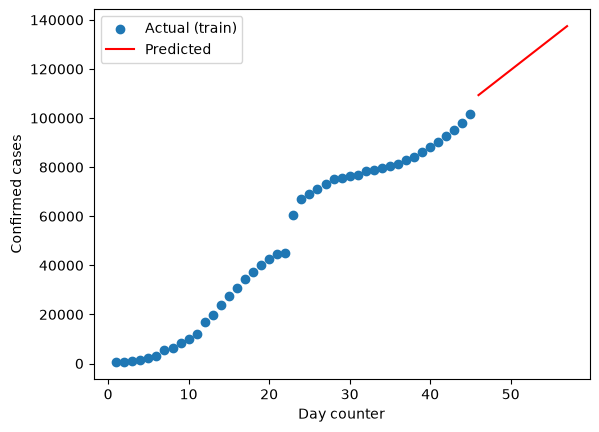

In [13]:
plt.scatter(X_train, y_train, label='Actual (train)')
plt.plot(X_test, y_p, color='red', label='Predicted')
plt.xlabel('Day counter')
plt.ylabel('Confirmed cases')
plt.legend()
plt.show()

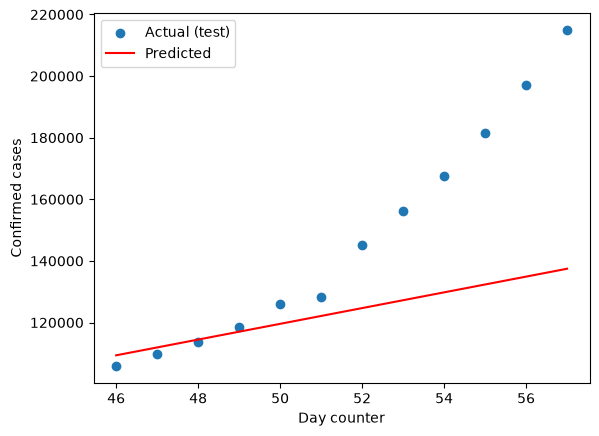

In [14]:
plt.scatter(X_test, y_test, label='Actual (test)')
plt.plot(X_test, y_p, color='red', label='Predicted')
plt.xlabel('Day counter')
plt.ylabel('Confirmed cases')
plt.legend()
plt.show()

In [15]:
daily_grouped_numbers.head(10)

,confirmed,deaths,recovered,day_counter,infected
0,555.0,17.0,28.0,1,510.0
1,653.0,18.0,30.0,2,605.0
2,941.0,26.0,36.0,3,879.0
3,1438.0,42.0,39.0,4,1357.0
4,2118.0,56.0,52.0,5,2010.0
5,2927.0,82.0,61.0,6,2784.0
6,5578.0,131.0,107.0,7,5340.0
7,6165.0,133.0,126.0,8,5906.0
8,8235.0,171.0,143.0,9,7921.0
9,9925.0,213.0,222.0,10,9490.0


In [16]:
mae = mean_absolute_error(y_test, y_p)
rmse = np.sqrt(mean_squared_error(y_test, y_p))
r2 = r2_score(y_test, y_p)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  24708.90
RMSE: 35435.64
R²:   -0.0305


In [17]:
# Death prediction
d = daily_grouped_numbers['deaths'] 
X_train, X_test, d_train, d_test = train_test_split(X,d, test_size=0.2, random_state=42, shuffle=False)
model = LinearRegression()
model.fit(X_train, d_train)
d_p = model.predict(X_test)
d_p


array([3518.51010101, 3606.66754502, 3694.82498902, 3782.98243303,
       3871.13987703, 3959.29732104, 4047.45476504, 4135.61220905,
       4223.76965305, 4311.92709706, 4400.08454106, 4488.24198507])

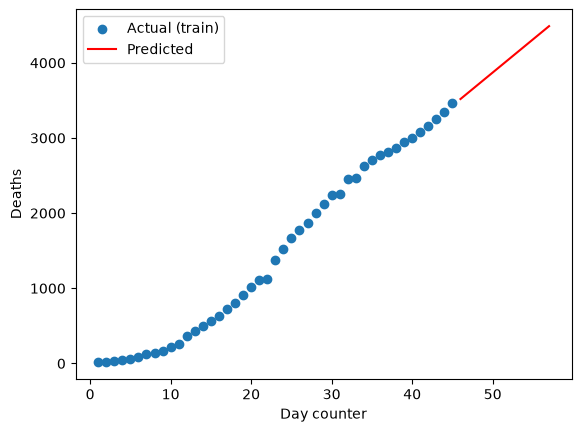

In [18]:
plt.scatter(X_train, d_train, label='Actual (train)')
plt.plot(X_test, d_p, color='red', label='Predicted')
plt.xlabel('Day counter')
plt.ylabel('Deaths')
plt.legend()
plt.show()

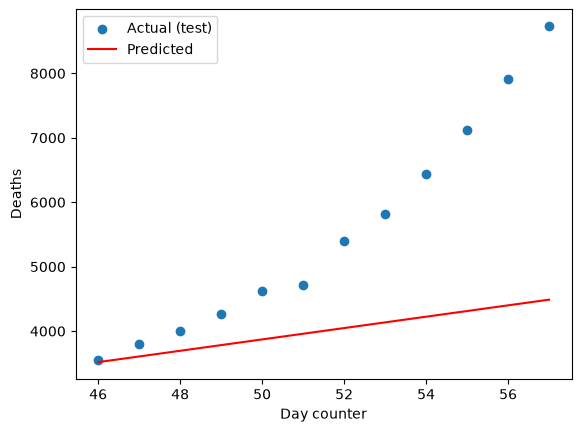

In [19]:
plt.scatter(X_test, d_test, label='Actual (test)')
plt.plot(X_test, d_p, color='red', label='Predicted')
plt.xlabel('Day counter')
plt.ylabel('Deaths')
plt.legend()
plt.show()

In [20]:
mae = mean_absolute_error(d_test, d_p)
rmse = np.sqrt(mean_squared_error(d_test, d_p))
r2 = r2_score(d_test, d_p)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  1528.37
RMSE: 2026.89
R²:   -0.5552
